In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error)

In [125]:
df = pd.read_csv(
    "Allsharkteeth.csv", 
    skipinitialspace = True
)
data_frame = df.copy(deep=True)
#data_frame

In [126]:
# Dropping cusplet measurements and non-shark data
cusplet_cols = [
    "LCH",
    "LCW",
    "CDS"
]

data_frame = data_frame.drop(columns=cusplet_cols)
data_frame = data_frame[data_frame["Taxon"] != "Onchopristis dunklei"]

In [127]:
measurement_cols = [
    "BCW",
    "CH",
    "DCL",
    "IDCL",
    "IMCL",
    "MCL",
    "PCH",
    "PCW",
    "RH",
    "RW",
    "TH",
    "DS",
    "RA"
]

# Replacing 0 values with NaN for measurement columns
data_frame[measurement_cols] = data_frame[measurement_cols].replace(0, np.nan)


In [ ]:
# Defining prediciton target and predictors
target = ""

predictors = [col for col in measurement_cols if col != target]

# Input measurements
X = data_frame[predictors]

# Measurement we're trying to predict
y = data_frame[target]

# Physical tooth grouping
groups = data_frame["Specimen #"]

# Cannot train a model to predict a measurement if measurement is missing
model_df = data_frame[data_frame[target].notna()].copy()

In [129]:
# 1. Fill missing predictor values with the median
# 2. Fit ordinary linear regression
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("regression", LinearRegression())
])

In [ ]:
cv = GroupKFold(n_splits=5)
predictions = cross_val_predict(model, X, y, cv=cv, groups=groups)

In [132]:
# Evaluate model performance
r2 = r2_score(y, predictions)
mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))

print("Target measurement:", target)
print("Rows used:", len(model_df))
print("Physical tooth groups:", groups.nunique())

print()

print(f"R²:   {r2:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

Target measurement: DS
Rows used: 86
Physical tooth groups: 26

R²:   0.399
MAE:  7.701
RMSE: 10.038


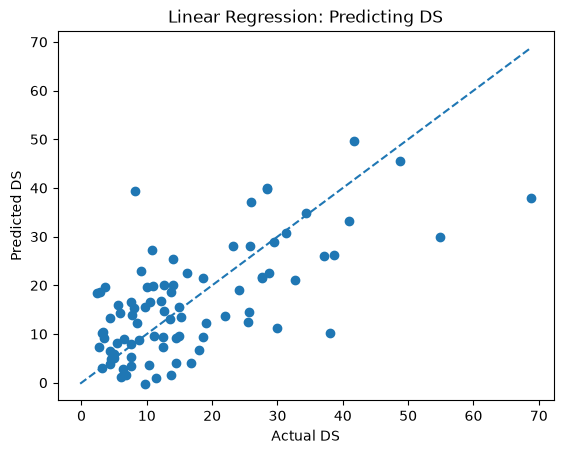

In [133]:
# Chat GPT used to generate the following code for plotting actual vs predicted values

plt.scatter(
    y,
    predictions
)

minimum = min(
    y.min(),
    predictions.min()
)

maximum = max(
    y.max(),
    predictions.max()
)


# Perfect-prediction line
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    f"Actual {target}"
)

plt.ylabel(
    f"Predicted {target}"
)

plt.title(
    f"Linear Regression: Predicting {target}"
)

plt.show()

In [134]:
model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['BCW','CH','DCL',...,'RW','TH','RA']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=